# Question 5 — Speech Emotion Classification Using LSTM

## Complete Google Colab Notebook

### Objective

Build an **LSTM-based speech emotion classification system** using the open-source **RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)** dataset.

The notebook performs:

1. Dataset download
2. Dataset structure and label analysis
3. Class-distribution analysis
4. Audio preprocessing
5. MFCC sequence extraction
6. Train/test split by speaker
7. LSTM model construction
8. Model training
9. Accuracy, precision, recall and F1-score evaluation
10. Confusion matrix
11. Example predictions
12. Final report and conclusion

### Selected dataset

**RAVDESS — Ryerson Audio-Visual Database of Emotional Speech and Song**

Dataset source: Zenodo

The speech portion contains 24 professional actors speaking two statements with different emotional expressions. The speech files contain eight emotion classes:

- Neutral
- Calm
- Happy
- Sad
- Angry
- Fearful
- Disgust
- Surprised

The emotion label is encoded in each filename, which makes the dataset convenient for supervised learning.

# 1. Dataset Description

## Why RAVDESS?

RAVDESS was selected because:

- It is an open research dataset.
- It contains labeled emotional speech.
- The audio files have a consistent naming structure.
- It contains multiple emotion classes.
- It is suitable for MFCC-based sequential modeling.
- It is small enough to use in Google Colab.
- It is widely used for speech-emotion-recognition experiments.

## Filename structure

A typical RAVDESS filename looks like:

```text
03-01-05-01-02-01-12.wav
```

The fields are:

```text
Modality
Vocal channel
Emotion
Emotional intensity
Statement
Repetition
Actor
```

The **third field** represents the emotion.

Emotion codes:

| Code | Emotion |
|---:|---|
| 01 | Neutral |
| 02 | Calm |
| 03 | Happy |
| 04 | Sad |
| 05 | Angry |
| 06 | Fearful |
| 07 | Disgust |
| 08 | Surprised |

# 2. Install Required Packages

This notebook uses:

- `librosa` — audio loading and MFCC extraction
- `soundfile` — WAV audio handling
- `scikit-learn` — splitting and evaluation metrics
- `seaborn` — confusion matrix visualization
- `tensorflow` — LSTM neural network

The TensorFlow installation cell only installs TensorFlow if it is not already available in Colab.

In [5]:
!pip -q install librosa soundfile scikit-learn seaborn requests tqdm

In [6]:
# TensorFlow is normally preinstalled in Google Colab.
# Install it only if it is missing.

try:
    import tensorflow as tf
    print("TensorFlow already available:", tf.__version__)
except ImportError:
    !pip -q install tensorflow
    import tensorflow as tf
    print("TensorFlow installed:", tf.__version__)

TensorFlow already available: 2.20.0


# 3. Import Libraries

In [7]:
import os
import re
import zipfile
import shutil
import time
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Masking
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Librosa:", librosa.__version__)

TensorFlow: 2.20.0
NumPy: 2.0.2
Librosa: 0.11.0


# 4. Download the RAVDESS Dataset

The speech audio archive is downloaded directly from Zenodo.

The complete speech archive is used, and the notebook can optionally limit the number of actors for faster experimentation.

### Recommended setting

`MAX_ACTORS = 24`

uses the complete speech dataset.

For a faster first test, use:

`MAX_ACTORS = 8`

After confirming that the notebook works, change it back to 24 for the final experiment.

In [4]:
DATA_ROOT = Path("/content/ravdess_data")
ZIP_PATH = Path("/content/ravdess_speech.zip")

# Complete dataset = 24 actors.
# For a quick test, change this to 8.
MAX_ACTORS = 24

DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Zenodo RAVDESS speech archive
RAVDESS_URL = (
    "https://zenodo.org/records/1188976/files/"
    "Audio_Speech_Actors_01-24.zip?download=1"
)

def download_file(url, destination):
    if destination.exists() and destination.stat().st_size > 0:
        print("Archive already exists:", destination)
        return

    print("Downloading RAVDESS speech dataset...")
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()

    total = int(response.headers.get("content-length", 0))

    with open(destination, "wb") as f:
        with tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            desc="RAVDESS"
        ) as pbar:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

    print("Download complete.")

download_file(RAVDESS_URL, ZIP_PATH)
print("Archive size:", round(ZIP_PATH.stat().st_size / (1024**2), 2), "MB")

RAVDESS:   0%|          | 0.00/208M [00:00<?, ?B/s]

Download complete.
Archive size: 198.81 MB


# 5. Extract Dataset

In [30]:
EXTRACT_DIR = Path("/content/ravdess_extracted")

if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True)

marker = EXTRACT_DIR / ".extracted"

if not marker.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    marker.touch()
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

wav_files = list(EXTRACT_DIR.rglob("*.wav"))

print("Total WAV files found:", len(wav_files))
print("Example:", wav_files[0] if wav_files else "No WAV files found")

Dataset already extracted.
Total WAV files found: 1440
Example: /content/ravdess_extracted/Actor_13/03-01-08-02-02-01-13.wav


# 6. Build a Metadata Table

We parse the RAVDESS filenames and create a table containing:

- File path
- Emotion code
- Emotion name
- Actor ID

This table is used for class-distribution analysis and speaker-independent train/test splitting.

In [9]:
EMOTION_MAP = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised"
}

records = []

for path in wav_files:

    parts = path.stem.split("-")

    if len(parts) != 7:
        continue

    modality = int(parts[0])
    vocal_channel = int(parts[1])
    emotion_code = int(parts[2])
    intensity = int(parts[3])
    statement = int(parts[4])
    repetition = int(parts[5])
    actor = int(parts[6])

    if emotion_code not in EMOTION_MAP:
        continue

    records.append({
        "path": str(path),
        "modality": modality,
        "vocal_channel": vocal_channel,
        "emotion_code": emotion_code,
        "emotion": EMOTION_MAP[emotion_code],
        "intensity": intensity,
        "statement": statement,
        "repetition": repetition,
        "actor": actor
    })

metadata = pd.DataFrame(records)

# Select actors if a smaller experiment is requested.
selected_actors = sorted(metadata["actor"].unique())[:MAX_ACTORS]
metadata = metadata[metadata["actor"].isin(selected_actors)].reset_index(drop=True)

print("Selected actors:", selected_actors)
print("Total selected audio files:", len(metadata))

display(metadata.head())

Selected actors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Total selected audio files: 1440


,path,modality,vocal_channel,emotion_code,emotion,intensity,statement,repetition,actor
0,/content/ravdess_extracted/Actor_13/03-01-08-0...,3,1,8,surprised,2,2,1,13
1,/content/ravdess_extracted/Actor_13/03-01-05-0...,3,1,5,angry,2,1,2,13
2,/content/ravdess_extracted/Actor_13/03-01-02-0...,3,1,2,calm,1,1,2,13
3,/content/ravdess_extracted/Actor_13/03-01-02-0...,3,1,2,calm,2,1,2,13
4,/content/ravdess_extracted/Actor_13/03-01-03-0...,3,1,3,happy,2,2,2,13


# 7. Study Dataset Structure and Class Distribution

Class distribution:


,count
emotion,
angry,192
calm,192
disgust,192
fearful,192
happy,192
neutral,96
sad,192
surprised,192


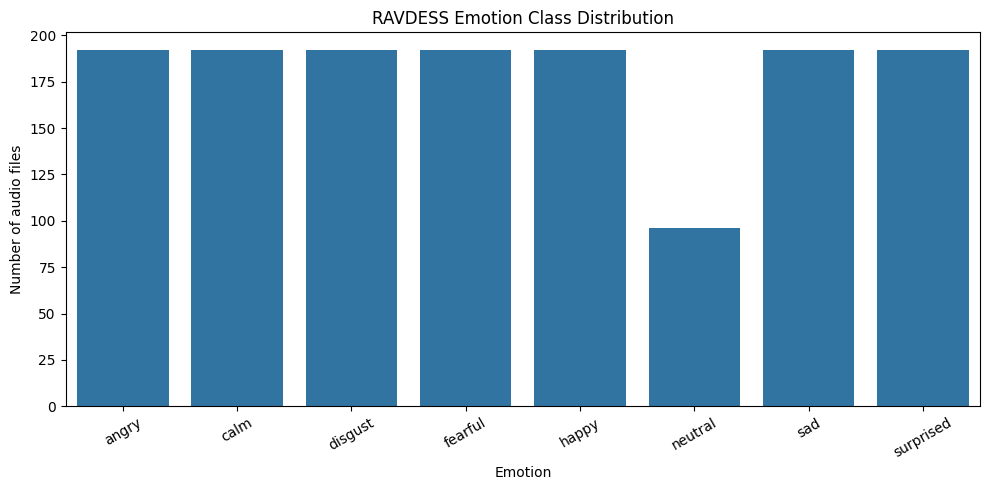

In [10]:
class_counts = (
    metadata["emotion"]
    .value_counts()
    .sort_index()
)

print("Class distribution:")
display(class_counts.to_frame("count"))

plt.figure(figsize=(10, 5))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)
plt.xlabel("Emotion")
plt.ylabel("Number of audio files")
plt.title("RAVDESS Emotion Class Distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Observation

RAVDESS is designed with a balanced distribution across its emotion classes. A balanced dataset is useful because the classifier is less likely to favor one emotion simply because that emotion has many more training examples.

# 8. Audio Inspection

Before extracting features, inspect one sample.

The waveform represents amplitude versus time.

For speech emotion classification, the important information is not only the overall waveform but also its frequency content and how that content changes over time.

File: /content/ravdess_extracted/Actor_13/03-01-08-02-02-01-13.wav
Sampling rate: 16000
Duration: 3.337 seconds


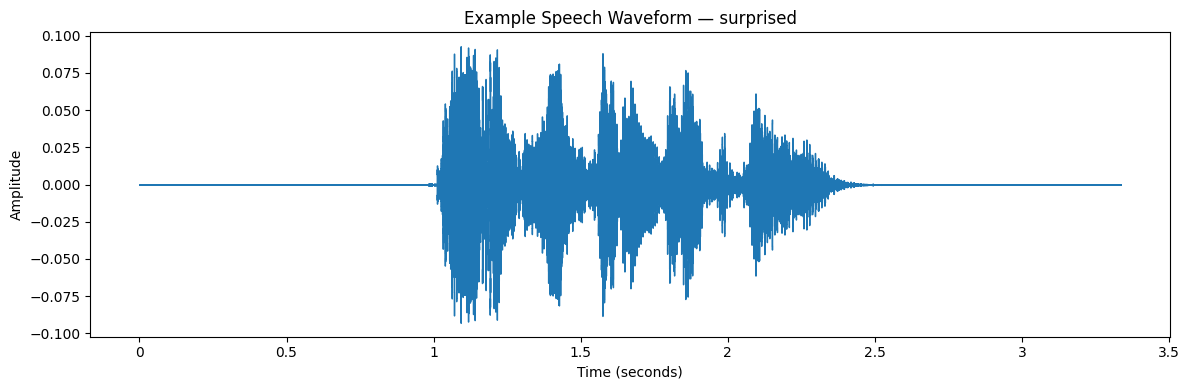

In [11]:
sample_path = metadata.iloc[0]["path"]

audio, sr = librosa.load(
    sample_path,
    sr=16000,
    mono=True
)

print("File:", sample_path)
print("Sampling rate:", sr)
print("Duration:", round(len(audio) / sr, 3), "seconds")

plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sr)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(
    "Example Speech Waveform — " +
    metadata.iloc[0]["emotion"]
)
plt.tight_layout()
plt.show()

# 9. Feature Extraction — MFCC Sequences

### Why MFCC?

Mel-Frequency Cepstral Coefficients (MFCCs) are widely used for speech analysis.

MFCC extraction converts the raw audio waveform into a sequence of acoustic feature vectors.

Instead of giving the LSTM one large waveform, we give it:

```text
Frame 1 → [MFCC1, MFCC2, ..., MFCC13]
Frame 2 → [MFCC1, MFCC2, ..., MFCC13]
Frame 3 → [MFCC1, MFCC2, ..., MFCC13]
...
Frame T → [MFCC1, MFCC2, ..., MFCC13]
```

Therefore, the LSTM input has the shape:

```text
(number of time frames, number of MFCC features)
```

For this experiment:

- Sample rate = 16 kHz
- MFCC coefficients = 40
- Hop length = 512 samples
- Maximum sequence length = 130 frames

Audio clips shorter than 130 frames are padded with zeros.

Longer clips are truncated to 130 frames.

This gives every sample the same input shape while preserving temporal ordering.

In [12]:
SAMPLE_RATE = 16000
N_MFCC = 40
N_FFT = 1024
HOP_LENGTH = 512
MAX_FRAMES = 130

def extract_mfcc(path):
    y, sr = librosa.load(
        path,
        sr=SAMPLE_RATE,
        mono=True
    )

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # Convert from:
    # (MFCC features, time)
    # to:
    # (time, MFCC features)
    mfcc = mfcc.T

    # Pad/truncate to fixed sequence length.
    if mfcc.shape[0] < MAX_FRAMES:
        pad_width = MAX_FRAMES - mfcc.shape[0]
        mfcc = np.pad(
            mfcc,
            ((0, pad_width), (0, 0)),
            mode="constant"
        )
    else:
        mfcc = mfcc[:MAX_FRAMES]

    return mfcc.astype(np.float32)

example_features = extract_mfcc(sample_path)

print("MFCC sequence shape:", example_features.shape)
print(
    "Meaning:",
    MAX_FRAMES,
    "time frames ×",
    N_MFCC,
    "MFCC features"
)

MFCC sequence shape: (130, 40)
Meaning: 130 time frames × 40 MFCC features


# 10. Visualize MFCC Features

The MFCC matrix shows how the acoustic characteristics of the speech change over time.

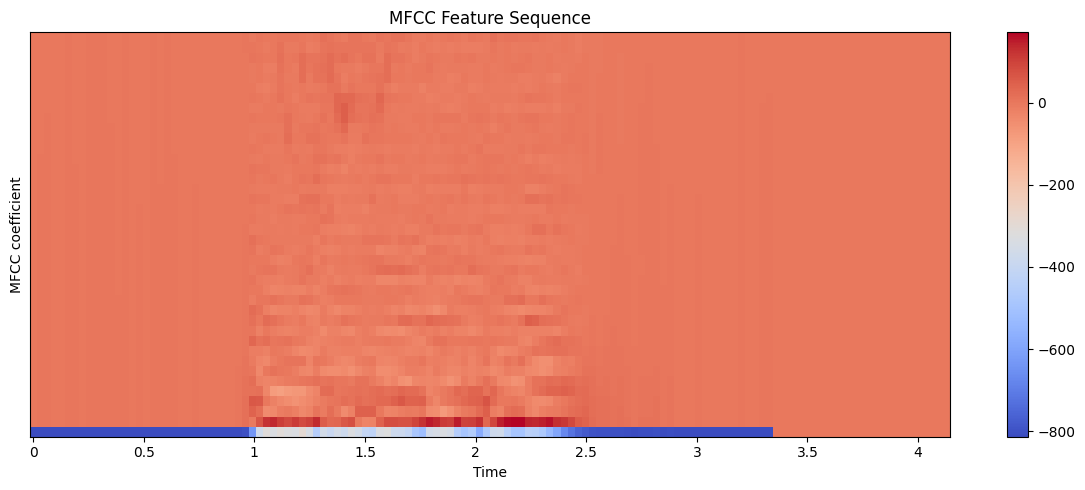

In [13]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    example_features.T,
    x_axis="time",
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH
)

plt.colorbar()
plt.xlabel("Time")
plt.ylabel("MFCC coefficient")
plt.title("MFCC Feature Sequence")
plt.tight_layout()
plt.show()

# 11. Extract MFCC Features for the Complete Dataset

The extracted feature tensor will have the shape:

```text
samples × time steps × MFCC features
```

For example, with 1440 audio files:

```text
1440 × 130 × 40
```

This is exactly the type of sequential input expected by an LSTM.

In [14]:
X = []
y = []
actors = []
paths = []

cache_path = Path(
    f"/content/mfcc_cache_{MAX_ACTORS}actors_{MAX_FRAMES}frames.npy"
)

labels_path = Path(
    f"/content/labels_cache_{MAX_ACTORS}actors.npy"
)

actors_path = Path(
    f"/content/actors_cache_{MAX_ACTORS}actors.npy"
)

if cache_path.exists() and labels_path.exists() and actors_path.exists():

    print("Loading cached MFCC features...")
    X = np.load(cache_path)
    y = np.load(labels_path)
    actors = np.load(actors_path)

    print("Cached feature shape:", X.shape)

else:

    print("Extracting MFCC features...")

    for row in tqdm(
        metadata.itertuples(index=False),
        total=len(metadata)
    ):
        try:
            features = extract_mfcc(row.path)

            X.append(features)
            y.append(row.emotion)
            actors.append(row.actor)
            paths.append(row.path)

        except Exception as e:
            print("Could not process:", row.path)
            print("Error:", e)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    actors = np.array(actors)

    np.save(cache_path, X)
    np.save(labels_path, y)
    np.save(actors_path, actors)

print("Feature tensor:", X.shape)
print("Labels:", y.shape)
print("Actors:", actors.shape)

Extracting MFCC features...


  0%|          | 0/1440 [00:00<?, ?it/s]

Feature tensor: (1440, 130, 40)
Labels: (1440,)
Actors: (1440,)


# 12. Normalize MFCC Features

Neural networks usually train better when features are normalized.

The mean and standard deviation are calculated **only from the training data** to avoid data leakage.

The same training statistics are then applied to the test data.

# 13. Speaker-Independent Train/Test Split

Speech emotion recognition can suffer from speaker leakage.

For example, if the same actor appears in both training and test sets, the model might learn characteristics of that speaker rather than emotion.

Therefore, this notebook splits the dataset by **actor**.

Actors used for training and testing are different.

This produces a more meaningful evaluation of emotion recognition on unseen speakers.

In [15]:
unique_actors = np.unique(actors)

train_actors, test_actors = train_test_split(
    unique_actors,
    test_size=0.25,
    random_state=42
)

train_mask = np.isin(actors, train_actors)
test_mask = np.isin(actors, test_actors)

X_train = X[train_mask]
X_test = X[test_mask]

y_train_text = y[train_mask]
y_test_text = y[test_mask]

print("Training actors:", sorted(train_actors.tolist()))
print("Testing actors:", sorted(test_actors.tolist()))

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

Training actors: [2, 3, 4, 5, 6, 7, 8, 11, 13, 14, 15, 16, 18, 20, 21, 22, 23, 24]
Testing actors: [1, 9, 10, 12, 17, 19]
X_train: (1080, 130, 40)
X_test : (360, 130, 40)


# 14. Label Encoding

The emotion names are converted into integer class labels.

Example:

```text
angry    → 0
calm     → 1
disgust  → 2
fearful  → 3
happy    → 4
neutral  → 5
sad      → 6
surprised→ 7
```

The exact numeric mapping is generated automatically by `LabelEncoder`.

In [16]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train_text)
y_test = label_encoder.transform(y_test_text)

class_names = label_encoder.classes_

print("Classes:")
for i, name in enumerate(class_names):
    print(i, "→", name)

print("Number of classes:", len(class_names))

Classes:
0 → angry
1 → calm
2 → disgust
3 → fearful
4 → happy
5 → neutral
6 → sad
7 → surprised
Number of classes: 8


# 15. Feature Normalization

The normalization parameters are calculated only from the training set.

Formula:

```text
normalized_x = (x - mean) / standard_deviation
```

The mean and standard deviation are calculated per MFCC coefficient.

In [17]:
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True)

train_std = np.where(
    train_std < 1e-6,
    1.0,
    train_std
)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("Training mean shape:", train_mean.shape)
print("Training std shape:", train_std.shape)
print("Normalized X_train:", X_train.shape)
print("Normalized X_test:", X_test.shape)

Training mean shape: (1, 1, 40)
Training std shape: (1, 1, 40)
Normalized X_train: (1080, 130, 40)
Normalized X_test: (360, 130, 40)


# 16. LSTM Architecture

The model receives a sequence of MFCC vectors.

Input shape:

```text
130 time steps × 40 features
```

Architecture:

```text
MFCC sequence
      ↓
Masking
      ↓
LSTM(128)
      ↓
Dropout(0.30)
      ↓
LSTM(64)
      ↓
Dropout(0.30)
      ↓
Dense(64, ReLU)
      ↓
Dense(8, Softmax)
      ↓
Emotion class
```

### Why LSTM?

LSTM is designed for sequential data.

Speech contains temporal information. The emotion-related characteristics can change across the duration of an utterance.

LSTM maintains an internal memory that allows information from earlier frames to influence later predictions.

In [18]:
NUM_CLASSES = len(class_names)

model = Sequential([
    Masking(
        mask_value=0.0,
        input_shape=(MAX_FRAMES, N_MFCC)
    ),

    LSTM(
        128,
        return_sequences=True
    ),

    Dropout(0.30),

    LSTM(
        64,
        return_sequences=False
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 130, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 130, 128)       │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 130, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,616 (549.28 KB)

 Trainable params: 140,616 (549.28 KB)

 Non-trainable params: 0 (0.00 B)

# 17. Training Configuration

Training parameters:

- Optimizer: Adam
- Initial learning rate: 0.001
- Loss: sparse categorical cross-entropy
- Batch size: 32
- Maximum epochs: 50
- Early stopping: patience 8
- Learning-rate reduction: patience 4

Early stopping helps prevent unnecessary training after validation performance stops improving.

In [19]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

start_training = time.perf_counter()

history = model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

training_time = time.perf_counter() - start_training

print(
    "Training time:",
    round(training_time / 60, 2),
    "minutes"
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 329ms/step - accuracy: 0.1580 - loss: 2.0618 - val_accuracy: 0.1728 - val_loss: 1.9740 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 306ms/step - accuracy: 0.2146 - loss: 1.9885 - val_accuracy: 0.2407 - val_loss: 1.9255 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 249ms/step - accuracy: 0.2723 - loss: 1.9005 - val_accuracy: 0.3210 - val_loss: 1.7872 - learning_rate: 0.0010
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 299ms/step - accuracy: 0.3083 - loss: 1.7435 - val_accuracy: 0.3210 - val_loss: 1.6483 - learning_rate: 0.0010
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 288ms/step - accuracy: 0.3192 - loss: 1.7036 - val_accuracy: 0.3580 - val_loss: 1.6494 - learning_rate: 0.0010
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 260ms/step - accuracy: 0.3420 - loss: 1.6370 - val_accuracy: 0.3765 - val_loss: 1.6157 - learning_rate: 0.0010
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 302ms/step - accuracy: 0.3998 - loss: 1.5485 -

# 18. Training Curves

Training and validation accuracy/loss are plotted to identify:

- Learning progress
- Overfitting
- Underfitting
- Convergence

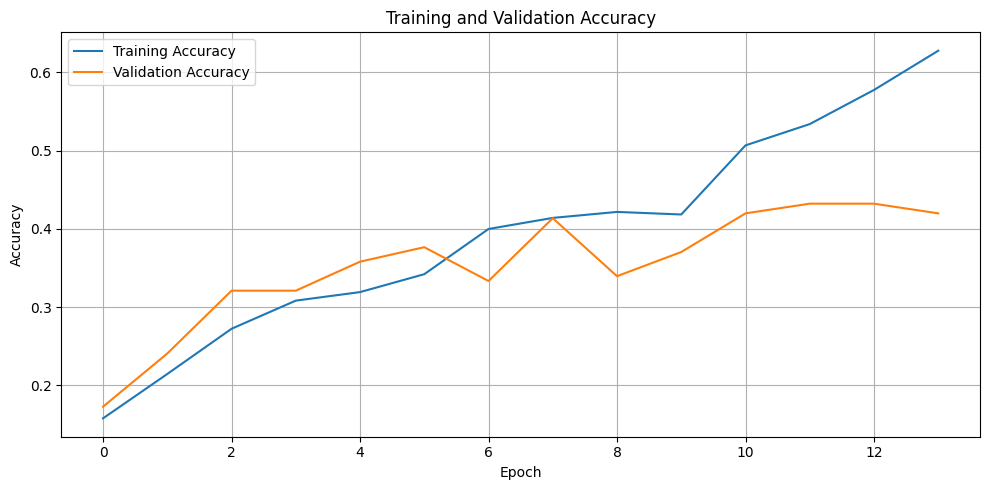

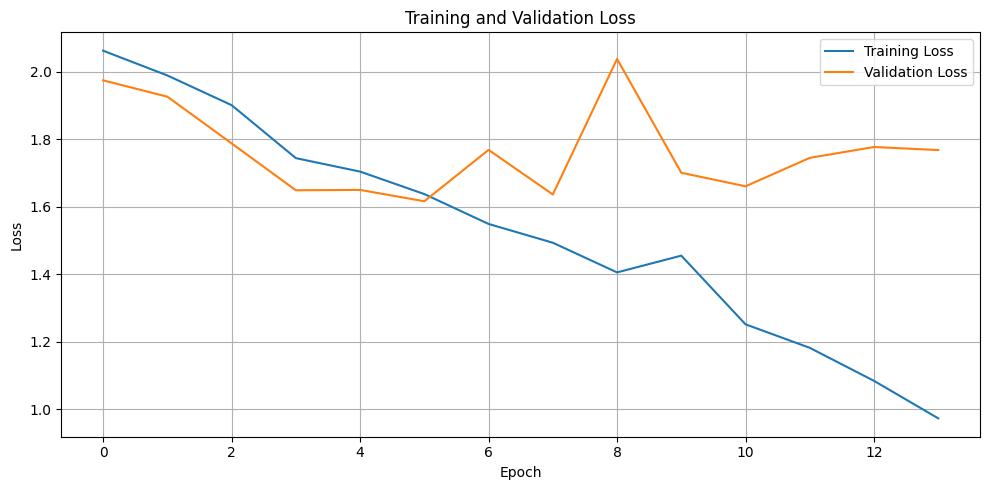

In [20]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 19. Test the LSTM Model

The test set contains speakers that were not used during training.

The model predicts a probability for every emotion class.

The class with the highest probability is selected as the final prediction.

In [21]:
test_probabilities = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    test_probabilities,
    axis=1
)

print("Predictions generated.")
print("Number of test samples:", len(y_test))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step
Predictions generated.
Number of test samples: 360


# 20. Accuracy

Accuracy is:

```text
Correct predictions / Total predictions
```

It represents the percentage of test samples classified correctly.

In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Test Accuracy: {accuracy * 100:.2f}%"
)

Test Accuracy: 32.78%


# 21. Precision, Recall and F1-Score

### Precision

Of the samples predicted as an emotion, how many were actually that emotion?

### Recall

Of all samples belonging to an emotion, how many were correctly detected?

### F1-score

F1 combines precision and recall:

```text
F1 = 2 × Precision × Recall / (Precision + Recall)
```

For multi-class classification, macro averages are reported so every emotion receives equal importance.

In [23]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1-score : {f1:.4f}")

Macro Precision: 0.3582
Macro Recall   : 0.3177
Macro F1-score : 0.3051


# 22. Detailed Classification Report

In [24]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

       angry     0.4828    0.2917    0.3636        48
        calm     0.4111    0.7708    0.5362        48
     disgust     0.4857    0.3542    0.4096        48
     fearful     0.5556    0.1042    0.1754        48
       happy     0.1884    0.2708    0.2222        48
     neutral     0.2500    0.1667    0.2000        24
         sad     0.1923    0.2083    0.2000        48
   surprised     0.3000    0.3750    0.3333        48

    accuracy                         0.3278       360
   macro avg     0.3582    0.3177    0.3051       360
weighted avg     0.3654    0.3278    0.3121       360



# 23. Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each emotion.

Rows represent the **true emotion**.

Columns represent the **predicted emotion**.

A strong classifier should have most values along the diagonal.

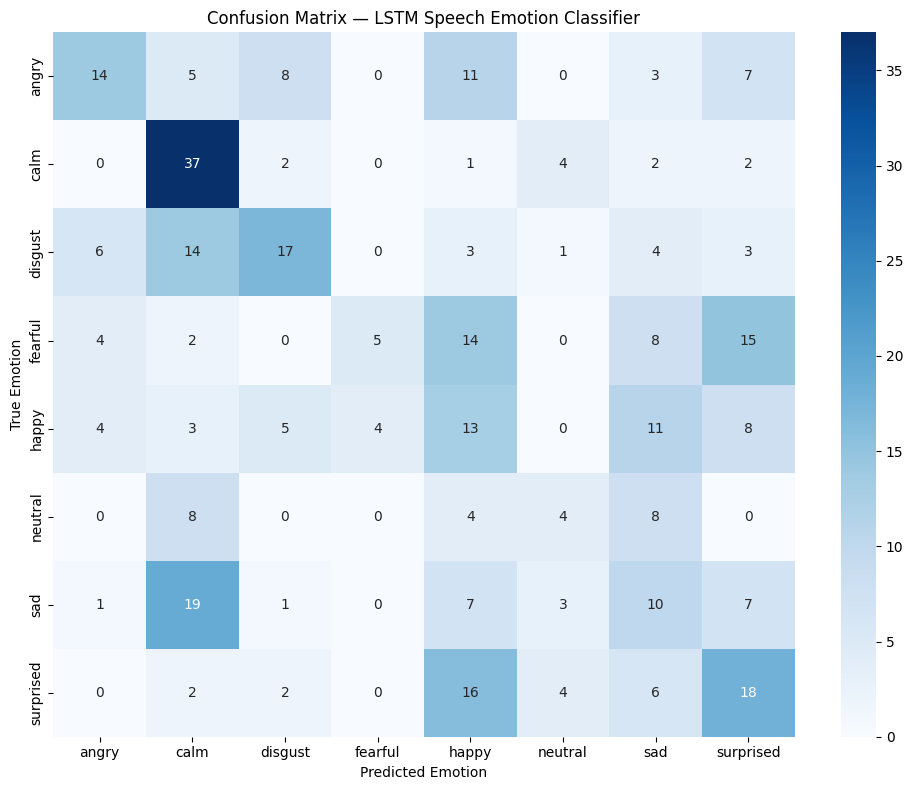

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Confusion Matrix — LSTM Speech Emotion Classifier")
plt.tight_layout()
plt.show()

# 24. Per-Class Accuracy

,Emotion,Accuracy
0,angry,0.291667
1,calm,0.770833
2,disgust,0.354167
3,fearful,0.104167
4,happy,0.270833
5,neutral,0.166667
6,sad,0.208333
7,surprised,0.375000


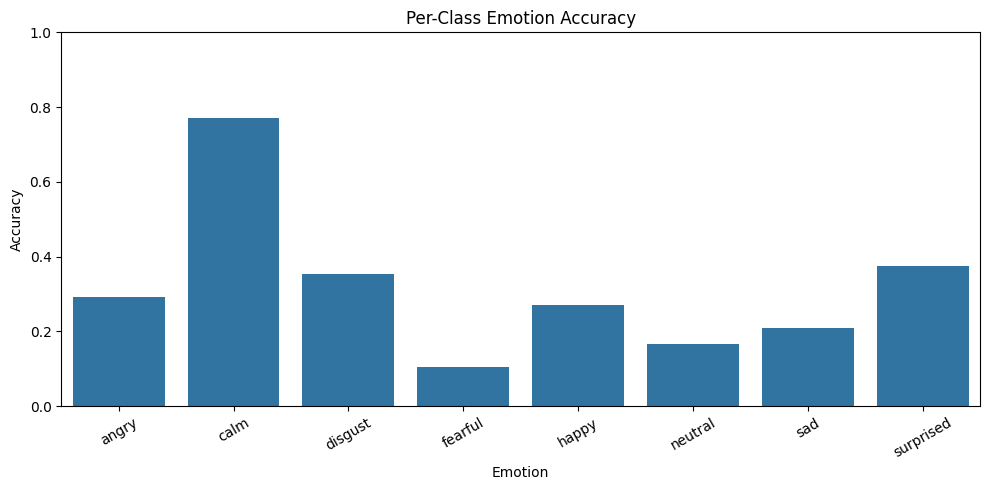

In [26]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({
    "Emotion": class_names,
    "Accuracy": per_class_accuracy
})

display(per_class_df)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=per_class_df,
    x="Emotion",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Emotion")
plt.title("Per-Class Emotion Accuracy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 25. Example Predictions

The following table shows the true emotion, predicted emotion and prediction confidence for test samples.

In [27]:
predicted_labels = label_encoder.inverse_transform(y_pred)
true_labels = label_encoder.inverse_transform(y_test)

confidence = np.max(
    test_probabilities,
    axis=1
)

prediction_df = pd.DataFrame({
    "True Emotion": true_labels,
    "Predicted Emotion": predicted_labels,
    "Confidence": confidence
})

display(
    prediction_df.head(20)
)

,True Emotion,Predicted Emotion,Confidence
0,calm,happy,0.229155
1,sad,neutral,0.229975
2,angry,disgust,0.699906
3,neutral,calm,0.385948
4,calm,calm,0.240212
5,disgust,angry,0.294176
6,disgust,sad,0.234146
7,disgust,disgust,0.598695
8,disgust,disgust,0.235607
9,surprised,surprised,0.341738


# 26. Misclassified Samples

Examining incorrect predictions helps explain the model's weaknesses.

Some emotions are acoustically similar. For example:

- Calm vs neutral
- Fearful vs surprised
- Sad vs calm
- Angry vs fearful

The exact confusion pattern should be discussed using the confusion matrix produced by this experiment.

In [28]:
misclassified = prediction_df[
    prediction_df["True Emotion"] !=
    prediction_df["Predicted Emotion"]
].copy()

print(
    "Misclassified test samples:",
    len(misclassified)
)

display(misclassified.head(20))

Misclassified test samples: 242


,True Emotion,Predicted Emotion,Confidence
0,calm,happy,0.229155
1,sad,neutral,0.229975
2,angry,disgust,0.699906
3,neutral,calm,0.385948
5,disgust,angry,0.294176
6,disgust,sad,0.234146
10,sad,disgust,0.237090
12,happy,fearful,0.351664
13,angry,disgust,0.668168
14,neutral,calm,0.300828


# 27. Final Evaluation Table

In [29]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Training Time (minutes)"
    ],
    "Result": [
        accuracy,
        precision,
        recall,
        f1,
        training_time / 60
    ]
})

display(evaluation_results)

,Metric,Result
0,Accuracy,0.327778
1,Macro Precision,0.358232
2,Macro Recall,0.317708
3,Macro F1-score,0.305063
4,Training Time (minutes),2.080789


# 28. Observations

The following observations should be based on the actual results generated above.

### Dataset

RAVDESS provides balanced emotional speech samples from multiple actors. The speaker-independent split makes the evaluation more realistic because test speakers are not present in training.

### Features

MFCCs transform the raw audio into compact acoustic features. Each audio clip becomes a time sequence of MFCC vectors.

### LSTM

The LSTM processes the MFCC vectors sequentially and learns temporal patterns associated with different emotions.

### Evaluation

Accuracy provides the overall classification performance. Precision, recall and F1-score provide additional information about class-wise performance.

The confusion matrix reveals which emotions are most frequently confused.

### Important limitation

Speech emotion recognition is difficult because emotional expression depends on:

- Speaker characteristics
- Pitch
- Speaking rate
- Loudness
- Pronunciation
- Recording conditions
- Similarity between emotions

Therefore, some emotions may be consistently confused even when the model is trained correctly.

# 29. Short Report

## Dataset Name and Source

The dataset used is the **Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS)**.

The speech audio is obtained from the official RAVDESS archive hosted on Zenodo.

## Reason for Selecting the Dataset

RAVDESS was selected because it is an open research dataset with clearly labeled emotional speech, multiple actors and eight emotion classes. Its filename structure makes the labels easy to extract programmatically.

## Preprocessing

The audio is loaded using Librosa at 16 kHz and converted to mono.

MFCCs are extracted from short overlapping audio frames.

The MFCC matrix is transposed so that each time frame becomes one LSTM timestep.

Each sequence is padded or truncated to 130 frames.

The training-set mean and standard deviation are used for normalization.

## Feature Extraction

40 MFCC coefficients are extracted from every audio frame.

The final feature representation has the shape:

```text
130 × 40
```

where:

- 130 = temporal frames
- 40 = MFCC features

## LSTM Architecture

The classifier contains:

```text
Input: 130 × 40
        ↓
Masking
        ↓
LSTM(128)
        ↓
Dropout(0.30)
        ↓
LSTM(64)
        ↓
Dropout(0.30)
        ↓
Dense(64, ReLU)
        ↓
Dropout(0.30)
        ↓
Dense(8, Softmax)
```

## Training Setup

- Optimizer: Adam
- Learning rate: 0.001
- Loss: Sparse categorical cross-entropy
- Batch size: 32
- Maximum epochs: 50
- Early stopping: enabled
- Learning-rate reduction: enabled

## Evaluation

The model is evaluated using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Confusion Matrix

The numerical values are generated automatically in the evaluation table.

## Conclusion

An LSTM-based speech emotion classifier was developed using MFCC feature sequences extracted from the RAVDESS dataset.

The MFCC sequence preserves temporal information from speech, allowing the LSTM to learn changes in acoustic characteristics over time.

The speaker-independent test split provides a more realistic evaluation because the test speakers are not used during training.

The final accuracy, precision, recall and F1-score indicate the effectiveness of the trained LSTM. The confusion matrix shows which emotions are easy or difficult for the model to distinguish.

Overall, the experiment demonstrates how sequential acoustic features such as MFCCs can be combined with LSTM networks for speech emotion classification.

# 31. References

1. S. Livingstone and F. Russo, “The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS),” PLOS ONE, 2018.
2. RAVDESS dataset, Zenodo: https://zenodo.org/records/1188976
3. Librosa documentation: https://librosa.org/
4. TensorFlow/Keras documentation: https://www.tensorflow.org/
5. Scikit-learn documentation: https://scikit-learn.org/